In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [2]:
df=pd.read_csv("combined_air_quality_modified.csv")
df = df.sort_values('date')
df.head()

,country,date,county,sitename,aqi,status,pm2.5,pm10,no,no2,nox,co,so2,o3,siteid
0,Philippines,2014-01-01 00:00:00,NCR,Manila,118.0,Unhealthy for Sensitive Groups,42.450712,105.388892,18.993939,68.680839,46.467632,1.180798,23.094493,12.319120,NaN
5040,Philippines,2014-01-01 00:00:00,Region III (Central Luzon),Meycauayan,26.0,Good,6.302583,10.918101,2.648880,8.695400,6.012469,0.203300,3.172664,45.924478,NaN
5184,Philippines,2014-01-01 00:00:00,Region III (Central Luzon),San Jose del Monte,76.0,Moderate,24.033763,52.575221,10.115224,39.272244,26.175358,0.764662,8.231972,51.624221,NaN
5328,Philippines,2014-01-01 00:00:00,Region III (Central Luzon),Tarlac City,127.0,Unhealthy for Sensitive Groups,45.860470,93.929349,30.888882,71.132085,54.071113,1.431131,26.992394,37.526762,NaN
5472,Philippines,2014-01-01 00:00:00,Region III (Central Luzon),Cabanatuan,102.0,Unhealthy for Sensitive Groups,35.887697,86.087306,15.365964,42.754659,30.803930,1.494187,10.458585,20.320952,NaN


In [3]:
features=['so2','co','o3','pm2.5','pm10','no2','nox','no']

status=['aqi']
X=df[features]
y=df[status]  


In [4]:
unique_dates = df['date'].unique()
split_idx = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_idx]

df_train = df[df['date'].isin(train_dates)].copy()
df_test = df[~df['date'].isin(train_dates)].copy()

In [5]:
scaler = StandardScaler()
df_train[features] = scaler.fit_transform(df_train[features])
df_test[features] = scaler.transform(df_test[features])

def create_sequences_by_station(dataframe, feature_cols, window_size=24):
    X_seq, y_seq = [], []
    # Group by station name to keep timelines fully isolated
    for station, group in dataframe.groupby('sitename'):
        group_sorted = group.sort_values('date')
        group_features = group_sorted[feature_cols].values
        group_targets = group_sorted['aqi'].values
        
        if len(group_sorted) > window_size:
            for i in range(len(group_sorted) - window_size):
                X_seq.append(group_features[i : (i + window_size)])
                y_seq.append(group_targets[i + window_size])
                
    return np.array(X_seq), np.array(y_seq)

# Build valid 3D shapes representing (Samples, 24 Hours, 8 Features)
X_train_seq, y_train_seq = create_sequences_by_station(df_train, features, window_size=24)
X_test_seq, y_test_seq = create_sequences_by_station(df_test, features, window_size=24)

print("Clean Train Sequence Shape:", X_train_seq.shape)
print("Clean Test Sequence Shape:", X_test_seq.shape)

Clean Train Sequence Shape: (112338, 24, 8)
Clean Test Sequence Shape: (24264, 24, 8)


In [6]:
model = tf.keras.Sequential([
# Input shape: (Time Steps, Features)
    layers.Input(shape=(24, 8)), 
    
    # First GRU layer 
    layers.GRU(256, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.4),
    
    # First GRU layer 
    layers.GRU(128, return_sequences=True),
    layers.BatchNormalization(), 
    layers.Dropout(0.3),
    

    # Third GRU layer
    layers.GRU(64),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    # Output Layer
    layers.Dense(1, activation='linear')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mae',
    metrics=['mae','mse'

    ]
)

In [8]:
# callback for saving checkpoint and early stop
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6
)

my_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(filepath='PhT_best_model_gxboost_regressor.keras', monitor='val_loss', save_best_only=True),
    reduce_lr
]

In [9]:
model.fit(
X_train_seq, y_train_seq,
epochs=100,
batch_size=256,
shuffle=True,
validation_split=0.2,
verbose=1,
callbacks=my_callbacks
)#training nn

Epoch 1/100


KeyboardInterrupt: 

In [15]:
best_model=tf.keras.models.load_model("PhT_best_model_gxboost_regressor.keras")

# 1. Generate pseudo-labels from the fully trained GRU model
print("Generating teacher pseudo-labels...")
nn_pseudo_labels = best_model.predict(X_train_seq)
y_pseudo_train = nn_pseudo_labels.flatten()

# 2. Flatten properly aligned 3D sequences into a 2D format for XGBoost
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat_sequences = X_test_seq.reshape(X_test_seq.shape[0], -1)

print("Training Optimized Student XGBoost Regressor...")
xgb_distilled = xgb.XGBRegressor(
    min_child_weight=1,
    n_estimators=150,     # Equivalent to trees grown sequentially
    max_depth=8,          # Controls structural complexity (prevents deep float splits from stalling)
    learning_rate=0.1,   # Step shrinkage size for gradient steps
    subsample=0.9,        # Percentage of sample data trained per step to reduce overfitting
    n_jobs=-1,            # Parallelized across CPU cores
    random_state=42,
    colsample_bytree=0.8

)
xgb_distilled.fit(X_train_flat, y_pseudo_train)

# 4. Predict and evaluate performance metrics
y_pred_xgb = xgb_distilled.predict(X_test_flat_sequences)

print("\n--- Corrected Distilled XGBoost Regression Performance ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_seq, y_pred_xgb):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_seq, y_pred_xgb):.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test_seq, y_pred_xgb)):.4f}")
print(f"R-squared (R2) Variance Score: {r2_score(y_test_seq, y_pred_xgb):.4f}")

Generating teacher pseudo-labels...
3511/3511 ━━━━━━━━━━━━━━━━━━━━ 61s 17ms/step
Training Optimized Student XGBoost Regressor...

--- Corrected Distilled XGBoost Regression Performance ---
Mean Absolute Error (MAE): 1.8953
Mean Squared Error (MSE): 11.2448
Root Mean Squared Error (RMSE): 3.3533
R-squared (R2) Variance Score: 0.9522


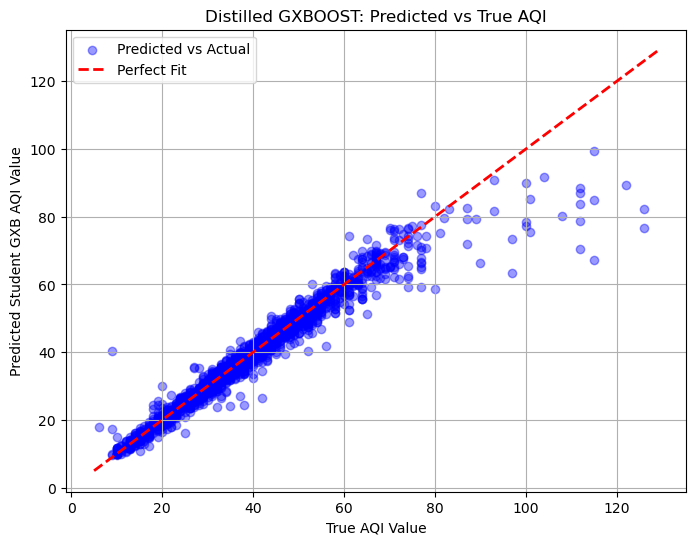

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_seq[:2000], y_pred_xgb[:2000], alpha=0.4, color='b', label='Predicted vs Actual')

# Plot accurate perfect diagonal trendline boundary
perfect_line = [min(y_test_seq), max(y_test_seq)]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.xlabel('True AQI Value')
plt.ylabel('Predicted Student GXB AQI Value')
plt.title('Distilled GXBOOST: Predicted vs True AQI')
plt.legend()
plt.grid(True)
plt.savefig('PhT_regression_fit_perf.png')

In [14]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the parameter space distribution
param_distributions = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

# 2. Initialize the baseline model
xgb_clf = xgb.XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

# 3. Set up Randomized Search (n_iter=10 trains 10 random combinations)
reg_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_distributions,
    n_iter=10, 
    cv=3, 
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

# 5. Run the search on the 2D flattened features and Teacher's pseudo-labels
print("Searching for the optimal XGBoost Regressor parameters...")
reg_search.fit(X_train_flat, y_pseudo_train)

# 6. Extract the best estimator configurations
print("\n✅ Best Parameters Found:", reg_search.best_params_)
best_xgb_reg = reg_search.best_estimator_

Searching for the optimal XGBoost Regressor parameters...

✅ Best Parameters Found: {'subsample': 0.9, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
